<a href="https://colab.research.google.com/github/kishorekrish1512-cloud/computer-vision/blob/main/exp01_segementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

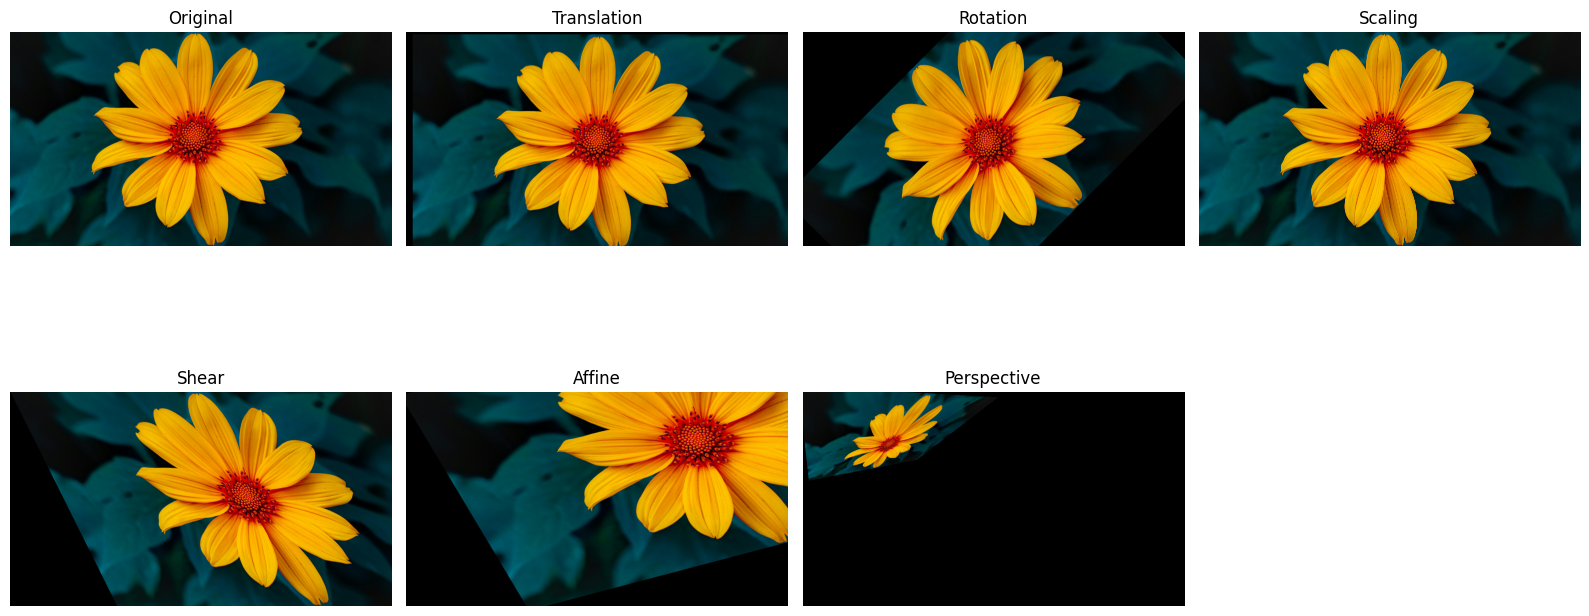

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- LOAD IMAGE ----------
img = cv2.imread("prem github.jpg")
if img is None:
    raise FileNotFoundError("Image not found.")

rows, cols, ch = img.shape

# ---------- 1. TRANSLATION ----------
M_trans = np.float32([[1, 0, 100], [0, 1, 50]])
dst_trans = cv2.warpAffine(img, M_trans, (cols, rows))

# ---------- 2. ROTATION ----------
center = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)
dst_rot = cv2.warpAffine(img, M_rot, (cols, rows))

# ---------- 3. SCALING ----------
dst_scale = cv2.resize(img, None, fx=1.5, fy=1.5)

# ---------- 4. SHEARING ----------
M_shear = np.float32([[1, 0.5, 0],
                      [0, 1, 0]])
dst_shear = cv2.warpAffine(img, M_shear, (cols, rows))

# ---------- 5. AFFINE ----------
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])
M_affine = cv2.getAffineTransform(pts1, pts2)
dst_affine = cv2.warpAffine(img, M_affine, (cols, rows))

# ---------- 6. PERSPECTIVE ----------
pts3 = np.float32([[56, 65], [368, 52], [28, 387], [389, 390]])
pts4 = np.float32([[0, 0], [300, 0], [0, 300], [300, 300]])
M_persp = cv2.getPerspectiveTransform(pts3, pts4)
dst_persp = cv2.warpPerspective(img, M_persp, (cols, rows))

# ---------- DISPLAY ----------
titles = ['Original', 'Translation', 'Rotation',
          'Scaling', 'Shear', 'Affine', 'Perspective']

images = [
    img,
    dst_trans,
    dst_rot,
    dst_scale,
    dst_shear,
    dst_affine,
    dst_persp
]

plt.figure(figsize=(16, 8))
for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [1]:
from google.colab import files
uploaded = files.upload()


Saving prem github.jpg to prem github.jpg
